# 1x H100 10-Minute Training Loss Curves

This notebook plots training-loss traces for our own local 1x H100 runs with a 10-minute training budget. The run list is intentionally hard-coded.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for candidate in (cur, *cur.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root from current working directory")

REPO_ROOT = find_repo_root(Path.cwd())
REPO_ROOT

PosixPath('/Users/robertgordan/Projects/parameter-golf')

In [7]:
RUNS = [
    {
        "label": "Baseline eval",
        "run_id": "20260322T230118Z_eval_path_compare_h100_baseline_20260322",
        "log": REPO_ROOT / ".runpod/results/20260322T230118Z_eval_path_compare_h100_baseline_20260322/stdout.log",
    },
    # {
    #     "label": "Strided eval",
    #     "run_id": "20260322T230203Z_eval_path_compare_h100_strided_20260322",
    #     "log": REPO_ROOT / ".runpod/results/20260322T230203Z_eval_path_compare_h100_strided_20260322/stdout.log",
    # },
    # {
    #     "label": "Baseline eval no-mid-val",
    #     "run_id": "20260323T164728Z_eval_path_compare_h100_baseline_noval_20260323",
    #     "log": REPO_ROOT / ".runpod/results/20260323T164728Z_eval_path_compare_h100_baseline_noval_20260323/stdout.log",
    # },
    # {
    #     "label": "Strided eval no-mid-val",
    #     "run_id": "20260323T164756Z_eval_path_compare_h100_strided_noval_20260323",
    #     "log": REPO_ROOT / ".runpod/results/20260323T164756Z_eval_path_compare_h100_strided_noval_20260323/stdout.log",
    # },
    # {
    #     "label": "Strided sanity rerun",
    #     "run_id": "20260323T194305Z_full_train_sanity_strided_20260323",
    #     "log": REPO_ROOT / ".runpod/results/20260323T194305Z_full_train_sanity_strided_20260323/stdout.log",
    # },
    {
        "label": "Recurrent 4/3x3/4",
        "run_id": "20260324T150928Z_recurrent_4_3x3_4_h100_10min_rerun_20260324",
        "log": REPO_ROOT / ".runpod/results/20260324T150928Z_recurrent_4_3x3_4_h100_10min_rerun_20260324/stdout.log",
    },
    {
        "label": "Int6 recur mlp3",
        "run_id": "20260324T165236Z_int6_recur_4_3x3_4_mlp3_baseline_h100_10min_20260324",
        "log": REPO_ROOT / ".runpod/results/20260324T165236Z_int6_recur_4_3x3_4_mlp3_baseline_h100_10min_20260324/stdout.log",
    },
    {
        "label": "Int6 recur mlp3 + fp16 recur",
        "run_id": "20260324T165315Z_int6_recur_4_3x3_4_mlp3_fp16recur_h100_10min_20260324",
        "log": REPO_ROOT / ".runpod/results/20260324T165315Z_int6_recur_4_3x3_4_mlp3_fp16recur_h100_10min_20260324/stdout.log",
    },
]

for run in RUNS:
    assert run["log"].exists(), f"Missing log: {run['log']}"

pd.DataFrame([{"label": r["label"], "run_id": r["run_id"], "log": str(r["log"].relative_to(REPO_ROOT))} for r in RUNS])

,label,run_id,log
0,Baseline eval,20260322T230118Z_eval_path_compare_h100_baseli...,.runpod/results/20260322T230118Z_eval_path_com...
1,Recurrent 4/3x3/4,20260324T150928Z_recurrent_4_3x3_4_h100_10min_...,.runpod/results/20260324T150928Z_recurrent_4_3...
2,Int6 recur mlp3,20260324T165236Z_int6_recur_4_3x3_4_mlp3_basel...,.runpod/results/20260324T165236Z_int6_recur_4_...
3,Int6 recur mlp3 + fp16 recur,20260324T165315Z_int6_recur_4_3x3_4_mlp3_fp16r...,.runpod/results/20260324T165315Z_int6_recur_4_...


In [8]:
TRAIN_RE = re.compile(
    r"step:(?P<step>\d+)/(?P<iters>\d+) train_loss:(?P<train_loss>\S+) train_time:(?P<train_time_ms>\d+)ms step_avg:(?P<step_avg_ms>\S+)ms"
)

def parse_train_log(label: str, run_id: str, path: Path) -> list[dict[str, object]]:
    rows = []
    for line in path.read_text(encoding="utf-8", errors="replace").splitlines():
        m = TRAIN_RE.search(line)
        if not m:
            continue
        rows.append(
            {
                "label": label,
                "run_id": run_id,
                "step": int(m.group("step")),
                "iters": int(m.group("iters")),
                "train_loss": float(m.group("train_loss")),
                "train_time_ms": int(m.group("train_time_ms")),
                "step_avg_ms": float(m.group("step_avg_ms")),
            }
        )
    return rows

rows = []
for run in RUNS:
    rows.extend(parse_train_log(run["label"], run["run_id"], run["log"]))

df = pd.DataFrame(rows)
df["train_time_min"] = df["train_time_ms"] / 60000.0
df["progress"] = df["step"] / df["step"].groupby(df["run_id"]).transform("max")
df.head()

,label,run_id,step,iters,train_loss,train_time_ms,step_avg_ms,train_time_min,progress
0,Baseline eval,20260322T230118Z_eval_path_compare_h100_baseli...,1,20000,6.9357,499,498.75,0.008317,0.001
1,Baseline eval,20260322T230118Z_eval_path_compare_h100_baseli...,2,20000,16.7499,998,499.13,0.016633,0.002
2,Baseline eval,20260322T230118Z_eval_path_compare_h100_baseli...,3,20000,8.7594,1506,501.86,0.025100,0.003
3,Baseline eval,20260322T230118Z_eval_path_compare_h100_baseli...,4,20000,6.5872,2024,505.96,0.033733,0.004
4,Baseline eval,20260322T230118Z_eval_path_compare_h100_baseli...,5,20000,6.6434,2525,505.03,0.042083,0.005


In [9]:
summary = (
    df.sort_values(["run_id", "step"])
      .groupby(["label", "run_id"], as_index=False)
      .agg(
          points=("step", "size"),
          max_step=("step", "max"),
          final_train_loss=("train_loss", "last"),
          final_train_time_min=("train_time_min", "last"),
          final_step_avg_ms=("step_avg_ms", "last"),
      )
      .sort_values("final_train_loss")
)
summary

,label,run_id,points,max_step,final_train_loss,final_train_time_min,final_step_avg_ms
2,Int6 recur mlp3 + fp16 recur,20260324T165315Z_int6_recur_4_3x3_4_mlp3_fp16r...,14,800,2.2435,9.334050,700.05
1,Int6 recur mlp3,20260324T165236Z_int6_recur_4_3x3_4_mlp3_basel...,14,800,2.2444,9.397017,704.78
3,Recurrent 4/3x3/4,20260324T150928Z_recurrent_4_3x3_4_h100_10min_...,14,800,2.2660,8.911000,668.33
0,Baseline eval,20260322T230118Z_eval_path_compare_h100_baseli...,15,1000,2.3322,8.635017,518.10


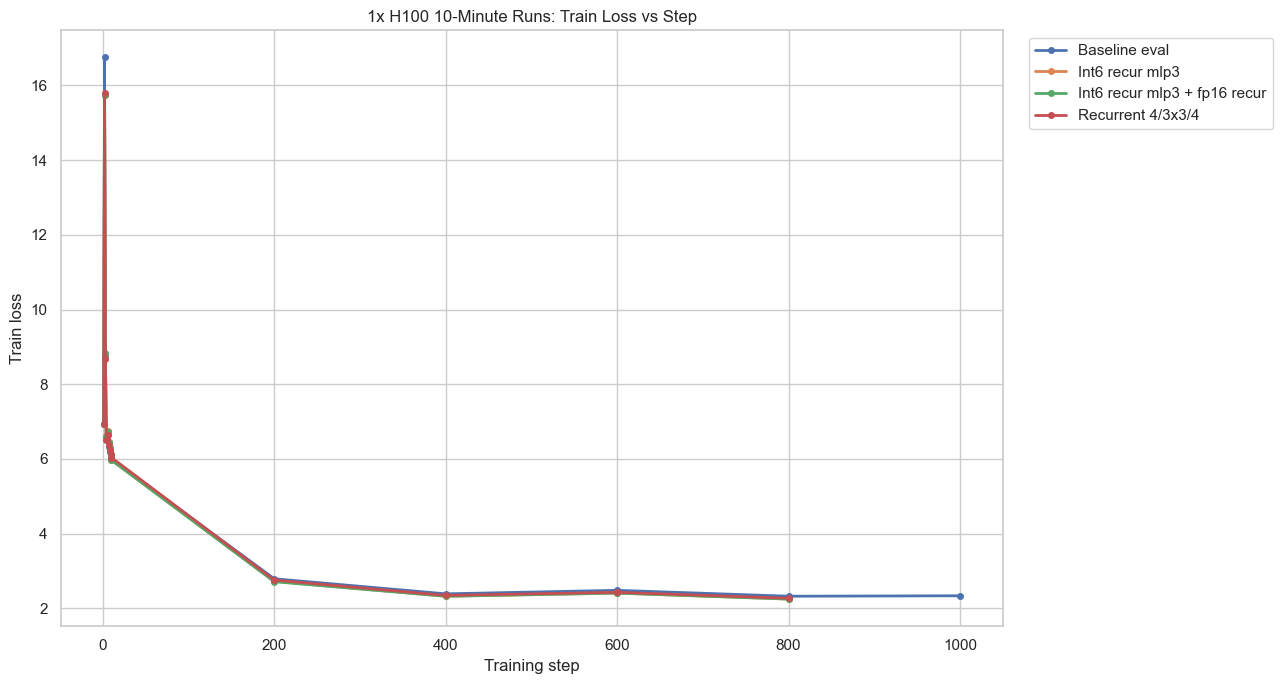

In [10]:
fig, ax = plt.subplots(figsize=(13, 7))
for label, g in df.groupby("label"):
    g = g.sort_values("step")
    ax.plot(g["step"], g["train_loss"], marker="o", linewidth=2, markersize=4, label=label)
ax.set_title("1x H100 10-Minute Runs: Train Loss vs Step")
ax.set_xlabel("Training step")
ax.set_ylabel("Train loss")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

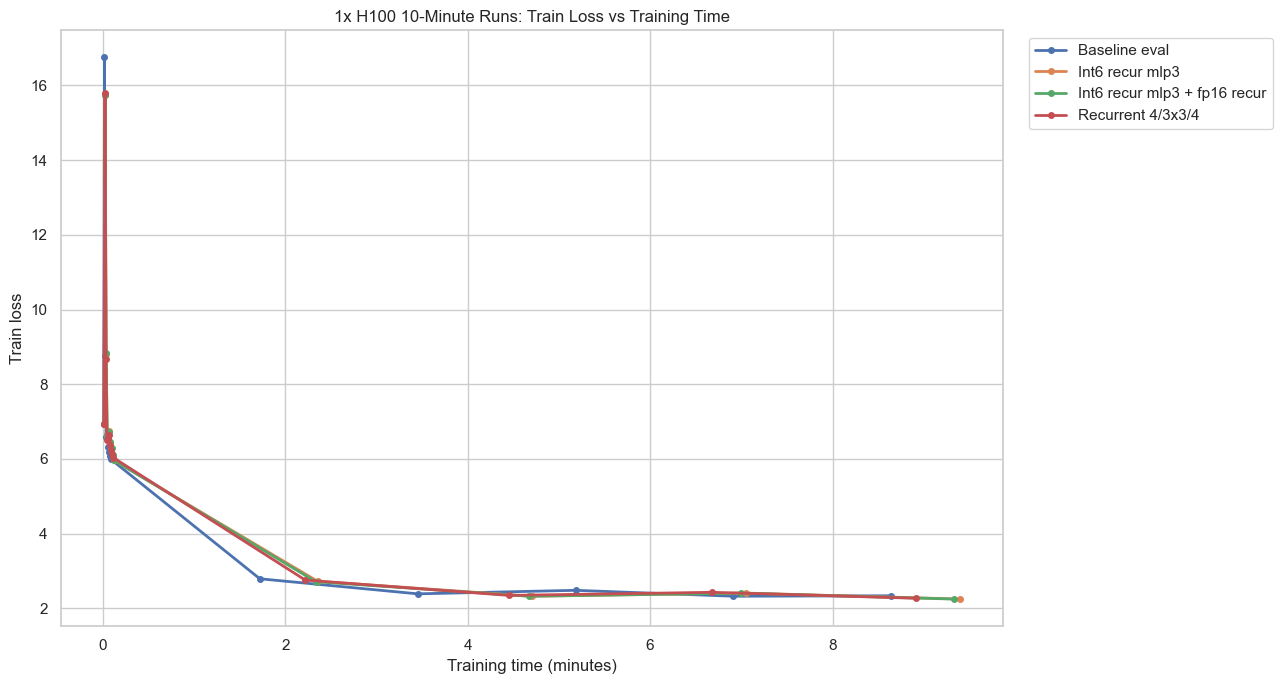

In [11]:
fig, ax = plt.subplots(figsize=(13, 7))
for label, g in df.groupby("label"):
    g = g.sort_values("train_time_min")
    ax.plot(g["train_time_min"], g["train_loss"], marker="o", linewidth=2, markersize=4, label=label)
ax.set_title("1x H100 10-Minute Runs: Train Loss vs Training Time")
ax.set_xlabel("Training time (minutes)")
ax.set_ylabel("Train loss")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()